# Aula 06 - Correlação

# Setup

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Carregando Dados de Felicidade

In [11]:
df = pd.read_excel('data/DataForTable2.1.xls')
df.head()

,Country name,year,Life Ladder,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Positive affect,Negative affect
0,Afghanistan,2008,3.723590,7.350416,0.450662,50.500000,0.718114,0.164055,0.881686,0.414297,0.258195
1,Afghanistan,2009,4.401778,7.508646,0.552308,50.799999,0.678896,0.187297,0.850035,0.481421,0.237092
2,Afghanistan,2010,4.758381,7.613900,0.539075,51.099998,0.600127,0.117861,0.706766,0.516907,0.275324
3,Afghanistan,2011,3.831719,7.581259,0.521104,51.400002,0.495901,0.160098,0.731109,0.479835,0.267175
4,Afghanistan,2012,3.782938,7.660506,0.520637,51.700001,0.530935,0.234157,0.775620,0.613513,0.267919


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2363 entries, 0 to 2362
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Country name                      2363 non-null   str    
 1   year                              2363 non-null   int64  
 2   Life Ladder                       2363 non-null   float64
 3   Log GDP per capita                2335 non-null   float64
 4   Social support                    2350 non-null   float64
 5   Healthy life expectancy at birth  2300 non-null   float64
 6   Freedom to make life choices      2327 non-null   float64
 7   Generosity                        2282 non-null   float64
 8   Perceptions of corruption         2238 non-null   float64
 9   Positive affect                   2339 non-null   float64
 10  Negative affect                   2347 non-null   float64
dtypes: float64(9), int64(1), str(1)
memory usage: 203.2 KB


## Calculando Correlação

Vamos usar ``corr`` para verificar correlação entre variáveis

In [16]:
# Calculando matriz de correlação
correlation_matrix = df.drop(columns=['Country name']).corr()
correlation_matrix

,year,Life Ladder,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Positive affect,Negative affect
year,1.000000,0.046840,0.080103,-0.043063,0.168026,0.232925,0.030903,-0.082090,0.013021,0.207702
Life Ladder,0.046840,1.000000,0.783561,0.722730,0.714920,0.538246,0.177347,-0.430568,0.515315,-0.352433
Log GDP per capita,0.080103,0.783561,1.000000,0.685348,0.819321,0.364857,-0.000796,-0.353937,0.230895,-0.260713
Social support,-0.043063,0.722730,0.685348,1.000000,0.597812,0.404230,0.065163,-0.221451,0.424608,-0.454834
Healthy life expectancy at birth,0.168026,0.714920,0.819321,0.597812,1.000000,0.375740,0.015119,-0.303168,0.218043,-0.150334
Freedom to make life choices,0.232925,0.538246,0.364857,0.404230,0.375740,1.000000,0.321404,-0.466064,0.578456,-0.278950
Generosity,0.030903,0.177347,-0.000796,0.065163,0.015119,0.321404,1.000000,-0.270021,0.300697,-0.071905
Perceptions of corruption,-0.082090,-0.430568,-0.353937,-0.221451,-0.303168,-0.466064,-0.270021,1.000000,-0.274248,0.265561
Positive affect,0.013021,0.515315,0.230895,0.424608,0.218043,0.578456,0.300697,-0.274248,1.000000,-0.334343
Negative affect,0.207702,-0.352433,-0.260713,-0.454834,-0.150334,-0.278950,-0.071905,0.265561,-0.334343,1.000000


Quando usamos ``df.drop(columns=['Country name'])`` não estamos efetivamente apagando a coluna ``Country name`` mas sim criando uma cópia do dataframe sem a coluna ``Country Name``. 

Fazemos isso porque só da pra verificar correlação entre variáveis ``numéricas``


Veja que é ruim olhar para a correlação na tabela. Por isso, vamos plotar um ``Heat Map`` e trazer isso visualmente.

## Plotando Correlação

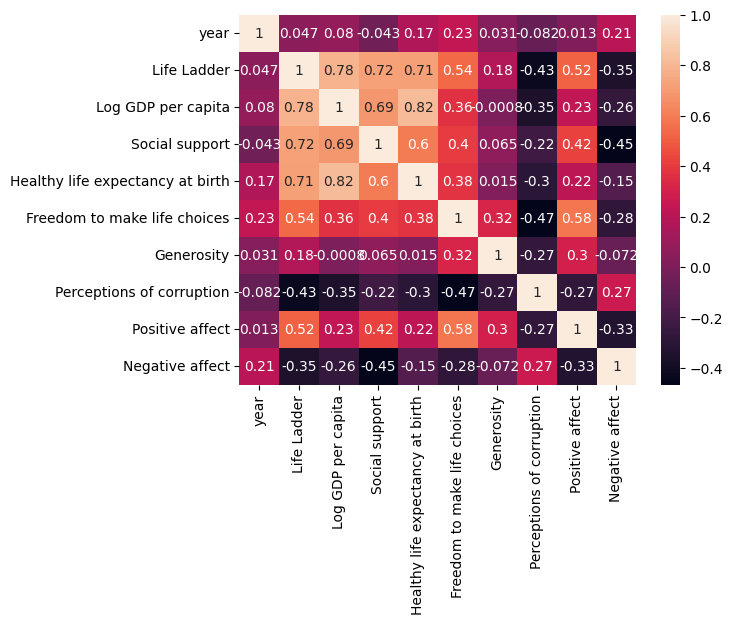

In [18]:
# Plota matriz de correlação
sns.heatmap(correlation_matrix, annot=True);

O uso ``annot=True`` anota os valores de correlação. 

Para entender melhor, vejamos o que acontece para ``ànnot=False``:

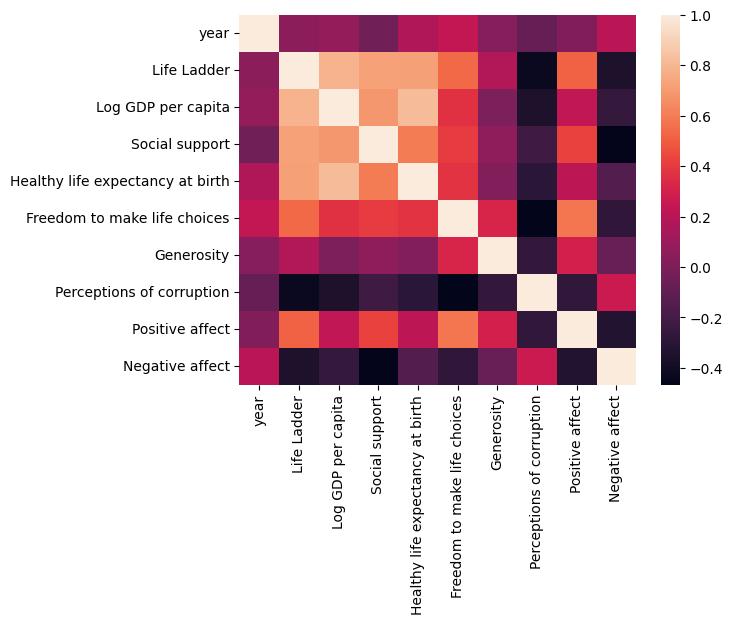

In [19]:
sns.heatmap(correlation_matrix, annot=False);

Conseguimos mudar a cor da escalar de cor, por exemplo:

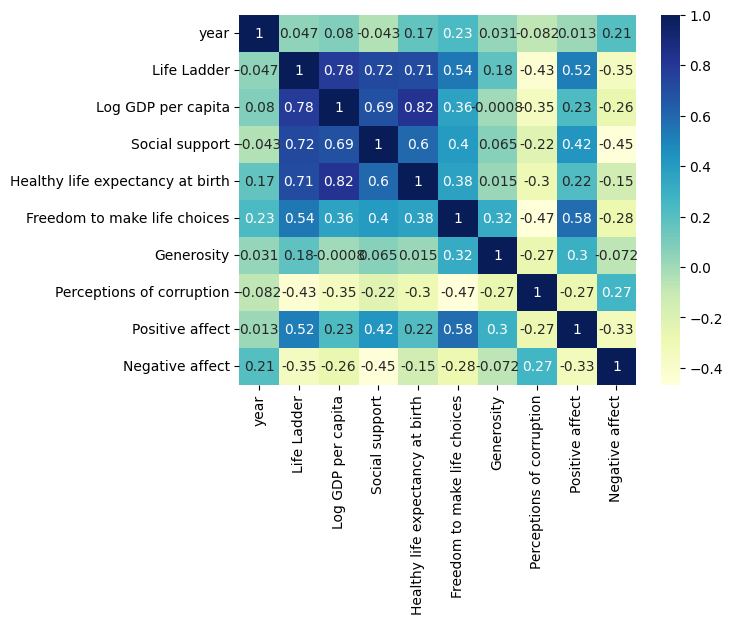

In [23]:
sns.heatmap(correlation_matrix, cmap='YlGnBu' ,annot=True);

In [27]:
df['Life Ladder'].describe()

count    2363.000000
mean        5.483562
std         1.125523
min         1.281271
25%         4.646750
50%         5.448725
75%         6.323592
max         8.018934
Name: Life Ladder, dtype: float64

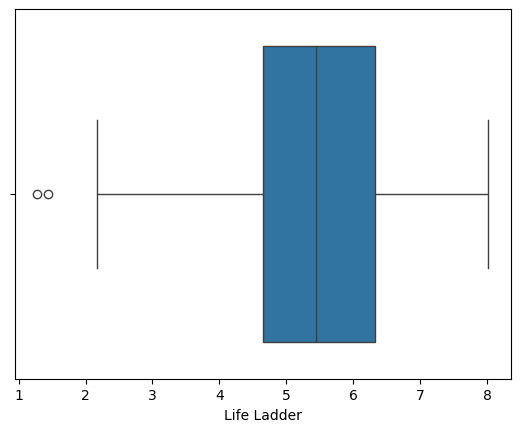

In [31]:
sns.boxplot(x=df['Life Ladder']);

In [36]:
# Quais são os países mais felizes?

df[df['Life Ladder'] > 6.3]['Country name'].unique()

<StringArray>
[                 'Algeria',                'Argentina',
                'Australia',                  'Austria',
                  'Bahrain',                  'Belgium',
                   'Belize',                   'Brazil',
                   'Canada',                    'Chile',
                 'Colombia',               'Costa Rica',
                  'Croatia',                   'Cyprus',
                  'Czechia',                  'Denmark',
              'El Salvador',                  'Estonia',
                  'Finland',                   'France',
                  'Germany',                   'Greece',
                'Guatemala',                  'Iceland',
                  'Ireland',                   'Israel',
                    'Italy',                  'Jamaica',
                    'Japan',                   'Kosovo',
                   'Kuwait',                   'Latvia',
                'Lithuania',               'Luxembourg',
                 

In [44]:
# Quais são os países menos felizes?

df[df['Life Ladder'] < 4.6]['Country name'].unique()

<StringArray>
[             'Afghanistan',                  'Albania',
                   'Angola',                  'Armenia',
               'Azerbaijan',               'Bangladesh',
                    'Benin',                 'Botswana',
                 'Bulgaria',             'Burkina Faso',
                  'Burundi',                 'Cambodia',
                 'Cameroon', 'Central African Republic',
                     'Chad',                    'China',
                  'Comoros',      'Congo (Brazzaville)',
         'Congo (Kinshasa)',                 'Djibouti',
                    'Egypt',                 'Eswatini',
                 'Ethiopia',                    'Gabon',
                   'Gambia',                  'Georgia',
                    'Ghana',                   'Guinea',
                    'Haiti',                    'India',
                     'Iran',                     'Iraq',
              'Ivory Coast',                   'Jordan',
                 

In [38]:
# Qual o país mais infeliz?
df.nsmallest(1, 'Life Ladder')

,Country name,year,Life Ladder,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Positive affect,Negative affect
13,Afghanistan,2022,1.281271,NaN,0.228217,54.875,0.368377,NaN,0.733198,0.205868,0.575512


In [39]:
# Qual o mais feliz?
df.nlargest(1, 'Life Ladder')

,Country name,year,Life Ladder,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Positive affect,Negative affect
539,Denmark,2005,8.018934,10.849012,0.972372,68.300003,0.971135,NaN,0.236522,0.776689,0.153672


## Comparando
Vamos trabalhar com três países:
- Brasil (baseline)
- Afeganistão
- Dinamarca

ANÁLISE DO: Brazil



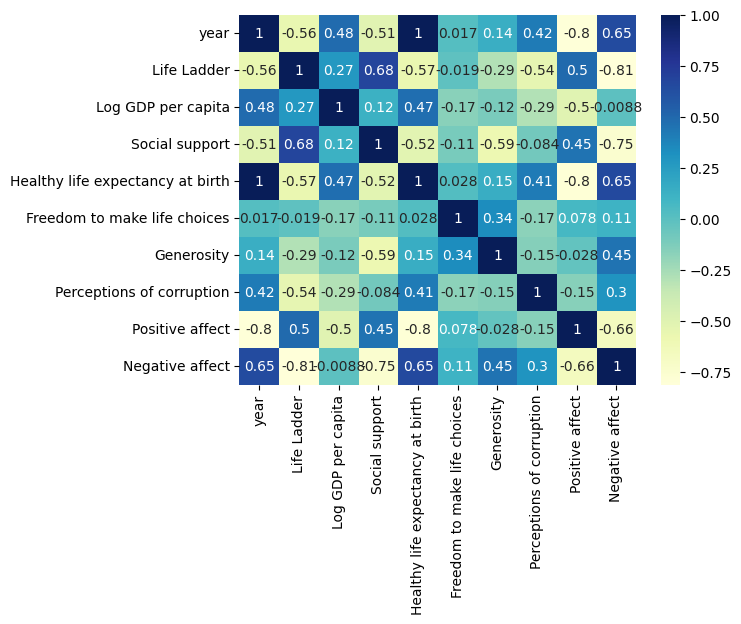





ANÁLISE DO: Denmark



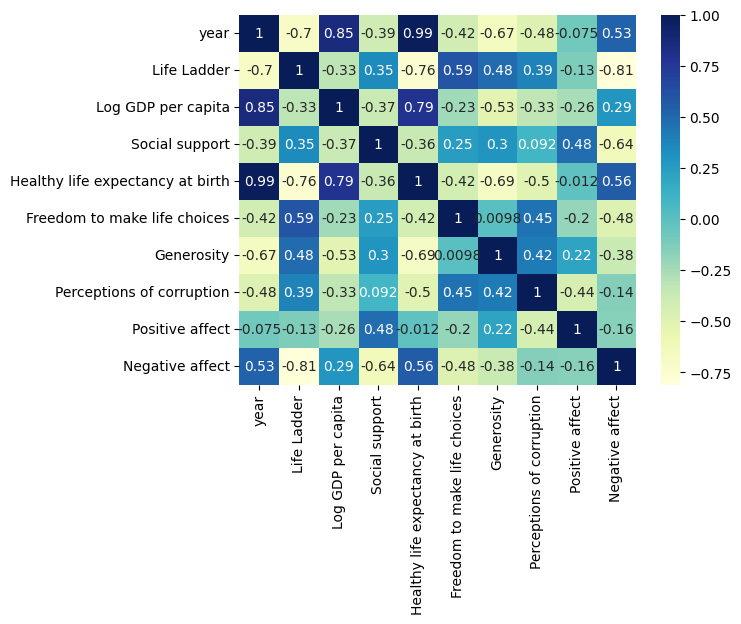





ANÁLISE DO: Afghanistan



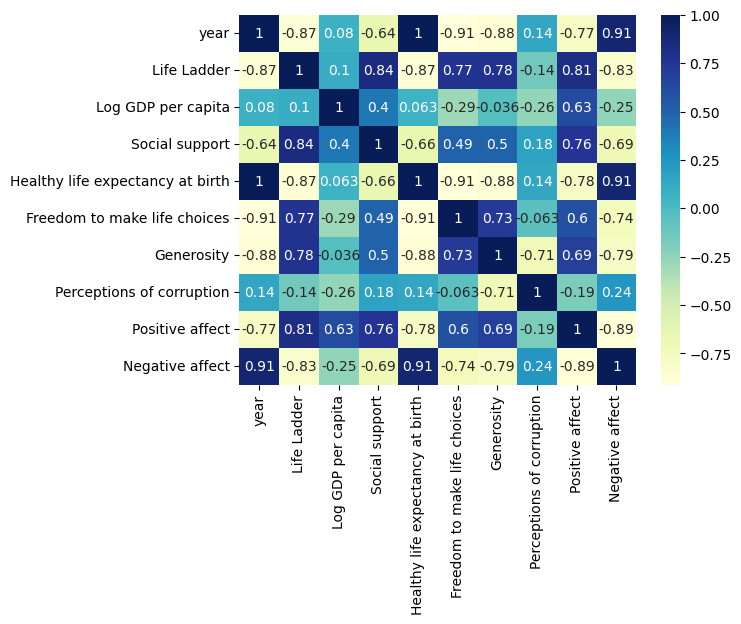

In [45]:
paises = ['Brazil', 'Denmark', 'Afghanistan']

for pais in paises:
    df_pais = df[df['Country name']==pais]
    matriz_corr = df_pais.drop(columns=['Country name']).corr()
    print(f'ANÁLISE DO: {pais}\n')
    sns.heatmap(matriz_corr, cmap='YlGnBu', annot=True)
    plt.show()
    print('\n\n\n')

# Carregando Dados de Consumo de açúcar

In [51]:
# Leitura da base de consumo de açúcar
sugar = pd.read_csv(
    'data/world_happiness_add_sugar.csv', 
    sep=';', 
    index_col=0
    )
sugar.head()

,country,grams_sugar_per_day
0,Finland,86.8
1,Denmark,152.0
2,Norway,120.0
3,Iceland,132.0
4,Netherlands,122.0


# Merge

In [54]:
# Alocando consumo de açucar na tabela de felicidade pelo Country name
df_sugar = pd.merge(df, sugar, left_on='Country name', right_on='country', how='left')
df_sugar.head()

,Country name,year,Life Ladder,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Positive affect,Negative affect,country,grams_sugar_per_day
0,Afghanistan,2008,3.723590,7.350416,0.450662,50.500000,0.718114,0.164055,0.881686,0.414297,0.258195,Afghanistan,24.5
1,Afghanistan,2009,4.401778,7.508646,0.552308,50.799999,0.678896,0.187297,0.850035,0.481421,0.237092,Afghanistan,24.5
2,Afghanistan,2010,4.758381,7.613900,0.539075,51.099998,0.600127,0.117861,0.706766,0.516907,0.275324,Afghanistan,24.5
3,Afghanistan,2011,3.831719,7.581259,0.521104,51.400002,0.495901,0.160098,0.731109,0.479835,0.267175,Afghanistan,24.5
4,Afghanistan,2012,3.782938,7.660506,0.520637,51.700001,0.530935,0.234157,0.775620,0.613513,0.267919,Afghanistan,24.5


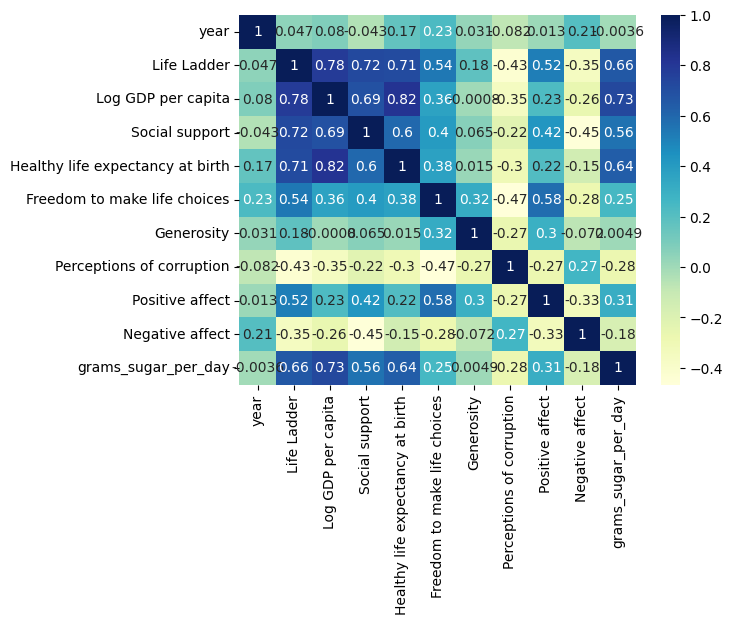

In [60]:
# Verificando a correlação como o consumo de açúcar
cm = df_sugar.drop(columns=['Country name', 'country']).corr()
sns.heatmap(cm, cmap='YlGnBu', annot=True);